# Treasury Yields

This notebook explores yield-to-maturity (YTM) calculations for U.S. Treasury securities using April 30, 2025 quote data.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

DATA_FILE = 'data/treasury_quotes_2025-04-30.xlsx'

## 1  YTM and Price

For a semiannual bond, the price $P$ and yield-to-maturity $y$ are related by:

$$P = \sum_{t=1}^{2T} \frac{c/2}{\left(1 + y/2\right)^t} + \frac{F}{\left(1 + y/2\right)^{2T}}$$

where $T$ is years to maturity, $c$ is the annual coupon rate (as a fraction), and $F$ is the face value.

In [6]:
def bond_price(ytm, T, cpn_rate, face=100):
    """
    Calculate the price of a semiannual bond.

    Parameters
    ----------
    ytm      : float  Annual yield-to-maturity (decimal, e.g. 0.05)
    T        : float  Years to maturity
    cpn_rate : float  Annual coupon rate (decimal, e.g. 0.03)
    face     : float  Face value (default 100)

    Returns
    -------
    float  Clean price
    """
    n = int(round(2 * T))          # number of semiannual periods
    coupon = face * cpn_rate / 2   # semiannual coupon payment
    r = ytm / 2                    # semiannual discount rate
    periods = np.arange(1, n + 1)
    pv_coupons = np.sum(coupon / (1 + r) ** periods)
    pv_face = face / (1 + r) ** n
    return pv_coupons + pv_face


def bond_ytm(price, T, cpn_rate, face=100, y0=0.05):
    """
    Solve implicitly for the YTM of a semiannual bond.

    Parameters
    ----------
    price    : float  Observed clean price
    T        : float  Years to maturity
    cpn_rate : float  Annual coupon rate (decimal)
    face     : float  Face value (default 100)
    y0       : float  Initial guess for YTM (default 5%)

    Returns
    -------
    float  Annual YTM (decimal)
    """
    def objective(y):
        return bond_price(y[0], T, cpn_rate, face) - price

    result = fsolve(objective, x0=[y0], full_output=True)
    return result[0][0]

### 1.1  Stylised Bond

Parameters: 30-year semiannual bond, 3% coupon, face value 100.

In [7]:
T       = 30
cpn     = 0.03
face    = 100

# Part 1: Price given YTM = 5%
ytm_given = 0.05
price_calc = bond_price(ytm_given, T, cpn, face)
print(f"1.1.1  YTM = {ytm_given:.1%}  →  Price = {price_calc:.4f}")

# Part 2: YTM given Price = 87
price_given = 87.0
ytm_calc = bond_ytm(price_given, T, cpn, face)
print(f"1.1.2  Price = {price_given:.2f}  →  YTM = {ytm_calc:.4%}")

# Sanity check: round-trip
price_check = bond_price(ytm_calc, T, cpn, face)
print(f"       Round-trip check: bond_price(ytm_calc) = {price_check:.4f} (should be {price_given})")

1.1.1  YTM = 5.0%  →  Price = 69.0913
1.1.2  Price = 87.00  →  YTM = 3.7231%
       Round-trip check: bond_price(ytm_calc) = 87.0000 (should be 87.0)


### 1.2  Data — Selected Quotes

We use the `selected quotes` tab, which contains notes with maturities spaced roughly six months apart.  
TTM values are used as-is (they are already approximately semiannual); we round to the nearest half-year for computing the number of coupon periods.

In [8]:
df_sel = pd.read_excel(DATA_FILE, sheet_name='selected quotes')

# Rename for convenience
df_sel = df_sel.rename(columns={'cpn rate': 'cpn_rate', 'ttm': 'TTM', 'ytm': 'ytm_data'})
df_sel['cpn_frac'] = df_sel['cpn_rate'] / 100   # percentage → decimal

display(df_sel[['KYTREASNO', 'type', 'TTM', 'cpn_rate', 'price', 'ytm_data']].head(10))

,KYTREASNO,type,TTM,cpn_rate,price,ytm_data
0,208129,note,0.503765,5.000,100.407236,0.041371
1,208213,note,0.999316,4.875,100.941008,0.039086
2,208302,note,1.503080,4.125,100.582031,0.037147
3,208385,note,1.998631,3.750,100.294922,0.035981
4,207960,note,2.502396,4.125,101.283203,0.035803
5,208044,note,3.000684,3.500,99.740234,0.035912
6,208132,note,3.504449,4.875,104.062500,0.036240
7,208216,note,4.000000,4.625,103.558594,0.036603
8,208305,note,4.503765,4.125,101.785156,0.036877
9,208388,note,4.999316,3.875,100.714844,0.037173


In [9]:
# 1.2.1  Calculate YTM for each issue
df_sel['ytm_calc'] = df_sel.apply(
    lambda row: bond_ytm(row['price'], row['TTM'], row['cpn_frac']),
    axis=1
)

df_sel['ytm_error_bps'] = (df_sel['ytm_calc'] - df_sel['ytm_data']) * 1e4

print("YTM comparison (data vs calculated):")
display(
    df_sel[['KYTREASNO', 'TTM', 'cpn_rate', 'price', 'ytm_data', 'ytm_calc', 'ytm_error_bps']]
    .round({'TTM': 3, 'ytm_data': 6, 'ytm_calc': 6, 'ytm_error_bps': 4})
)

print(f"\nMax absolute error : {df_sel['ytm_error_bps'].abs().max():.4f} bps")
print(f"Mean absolute error: {df_sel['ytm_error_bps'].abs().mean():.4f} bps")

YTM comparison (data vs calculated):


,KYTREASNO,TTM,cpn_rate,price,ytm_data,ytm_calc,ytm_error_bps
0,208129,0.504,5.000,100.407236,0.041371,0.041686,3.1471
1,208213,0.999,4.875,100.941008,0.039086,0.039063,-0.2313
2,208302,1.503,4.125,100.582031,0.037147,0.037224,0.7701
3,208385,1.999,3.750,100.294922,0.035981,0.035959,-0.2208
4,207960,2.502,4.125,101.283203,0.035803,0.035838,0.3466
5,208044,3.001,3.500,99.740234,0.035912,0.035921,0.0943
6,208132,3.504,4.875,104.062500,0.036240,0.036285,0.4521
7,208216,4.000,4.625,103.558594,0.036603,0.036605,0.0254
8,208305,4.504,4.125,101.785156,0.036877,0.036908,0.3074
9,208388,4.999,3.875,100.714844,0.037173,0.037170,-0.0242



Max absolute error : 3.1471 bps
Mean absolute error: 0.3796 bps


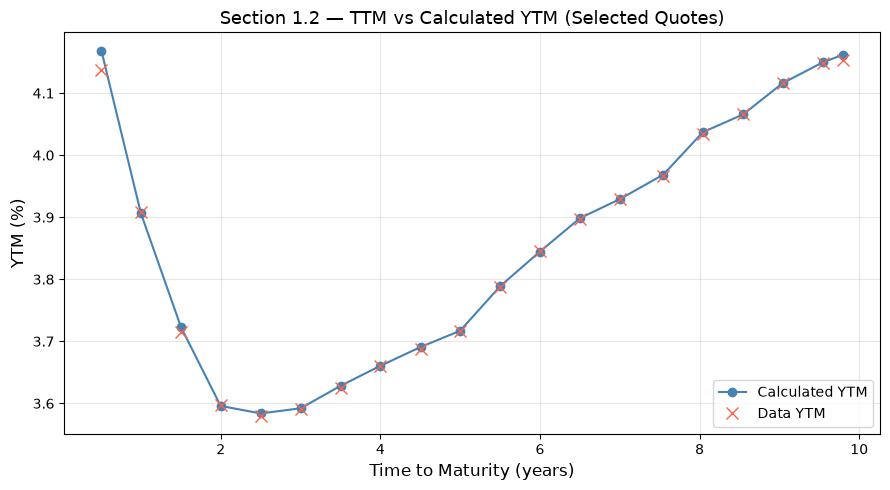

In [10]:
# 1.2.2  Plot TTM vs calculated YTM
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(df_sel['TTM'], df_sel['ytm_calc'] * 100, marker='o', linewidth=1.5,
        color='steelblue', label='Calculated YTM')
ax.plot(df_sel['TTM'], df_sel['ytm_data'] * 100, marker='x', linewidth=0,
        color='tomato', markersize=8, label='Data YTM')

ax.set_xlabel('Time to Maturity (years)', fontsize=12)
ax.set_ylabel('YTM (%)', fontsize=12)
ax.set_title('Section 1.2 — TTM vs Calculated YTM (Selected Quotes)', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2  Yields Across Maturities

We now use the full `quotes` tab and focus on **nominal securities** (excluding TIPS notes and TIPS bonds).

In [11]:
df_all = pd.read_excel(DATA_FILE, sheet_name='quotes')
df_all = df_all.rename(columns={'cpn rate': 'cpn_rate', 'ttm': 'TTM', 'ytm': 'ytm_data'})
df_all['cpn_frac'] = df_all['cpn_rate'] / 100

# Exclude TIPS
df_nom = df_all[~df_all['type'].isin(['TIPS note', 'TIPS bond'])].copy()

print(f"Full dataset: {len(df_all)} rows")
print(f"Nominal only: {len(df_nom)} rows")
print(f"Types present: {sorted(df_nom['type'].unique())}")

Full dataset: 449 rows
Nominal only: 396 rows
Types present: ['bill', 'bond', 'note']


### 2.1  TTM vs Provided YTM (Nominal Securities)

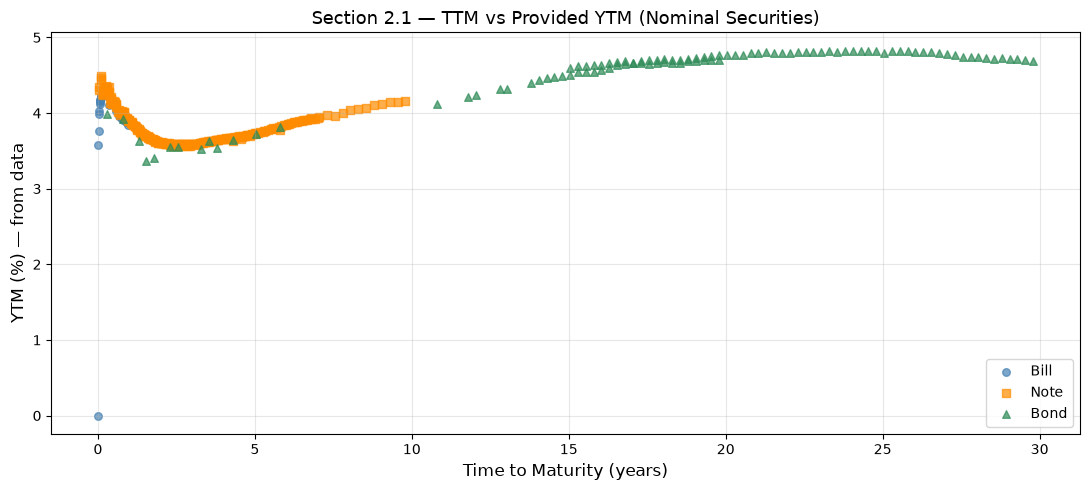

In [12]:
df_nom_has_ytm = df_nom.dropna(subset=['ytm_data'])

fig, ax = plt.subplots(figsize=(11, 5))

for bond_type, color, marker in [
    ('bill',  'steelblue', 'o'),
    ('note',  'darkorange', 's'),
    ('bond',  'seagreen',   '^'),
]:
    subset = df_nom_has_ytm[df_nom_has_ytm['type'] == bond_type]
    if not subset.empty:
        ax.scatter(subset['TTM'], subset['ytm_data'] * 100,
                   label=bond_type.capitalize(), color=color, marker=marker,
                   alpha=0.7, s=30)

ax.set_xlabel('Time to Maturity (years)', fontsize=12)
ax.set_ylabel('YTM (%) — from data', fontsize=12)
ax.set_title('Section 2.1 — TTM vs Provided YTM (Nominal Securities)', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2.2  Calculate YTM for All Nominal Bonds & Notes

Bills (zero-coupon) are excluded here — they are handled in §2.3 via discount yields.

In [13]:
# Non-bill nominals (notes and bonds have coupons)
df_coupon = df_nom[df_nom['type'] != 'bill'].copy()

df_coupon['ytm_calc'] = df_coupon.apply(
    lambda row: bond_ytm(row['price'], row['TTM'], row['cpn_frac']),
    axis=1
)

# 2.2.2  Error vs data-provided YTM
has_ytm = df_coupon['ytm_data'].notna()
df_coupon.loc[has_ytm, 'ytm_error_bps'] = (
    df_coupon.loc[has_ytm, 'ytm_calc'] - df_coupon.loc[has_ytm, 'ytm_data']
) * 1e4

print("Error statistics (calculated vs data YTM, basis points):")
err = df_coupon.loc[has_ytm, 'ytm_error_bps']
print(f"  Mean abs error : {err.abs().mean():.4f} bps")
print(f"  Max abs error  : {err.abs().max():.4f} bps")
print(f"  Std of errors  : {err.std():.4f} bps")

Error statistics (calculated vs data YTM, basis points):
  Mean abs error : 10.2059 bps
  Max abs error  : 202.5572 bps
  Std of errors  : 24.6123 bps


In [14]:
# 2.2.3  Issues where data does NOT provide a YTM (all TIPS were excluded; remaining NaNs?)
missing_ytm = df_coupon[~has_ytm][['KYTREASNO', 'type', 'TTM', 'cpn_rate', 'price', 'ytm_calc']]

if missing_ytm.empty:
    print("All nominal coupon-bearing issues in the dataset have a provided YTM.")
else:
    print(f"Issues without a data-provided YTM ({len(missing_ytm)} rows):")
    display(missing_ytm.round({'TTM': 4, 'ytm_calc': 6}))

All nominal coupon-bearing issues in the dataset have a provided YTM.


In [15]:
# Summary table: data YTM vs calculated YTM for issues that have both
cols_show = ['KYTREASNO', 'type', 'TTM', 'cpn_rate', 'price', 'ytm_data', 'ytm_calc', 'ytm_error_bps']
display(
    df_coupon.loc[has_ytm, cols_show]
    .sort_values('TTM')
    .round({'TTM': 4, 'ytm_data': 6, 'ytm_calc': 6, 'ytm_error_bps': 4})
    .head(30)
)

,KYTREASNO,type,TTM,cpn_rate,price,ytm_data,ytm_calc,ytm_error_bps
4,207886,note,0.0411,2.750,99.935099,0.043463,0.050000,65.3706
6,206859,note,0.0411,2.125,99.911456,0.043043,0.050000,69.5701
11,207214,note,0.0849,2.875,99.865356,0.044653,0.050000,53.4697
12,208056,note,0.0849,4.250,99.977675,0.044915,0.050000,50.8521
13,207545,note,0.0849,0.250,99.649509,0.044315,0.050000,56.8506
18,207903,note,0.1259,2.875,99.827321,0.042513,0.050000,74.8654
23,208073,note,0.1670,4.625,100.055939,0.042942,0.050000,70.5836
24,207560,note,0.1670,0.250,99.342633,0.042422,0.050000,75.7819
25,207224,note,0.1670,2.750,99.754143,0.042484,0.050000,75.1574
31,207915,note,0.2081,3.000,99.728798,0.043316,0.050000,66.8396


### 2.3  Discount Yields for Treasury Bills

T-bills are zero-coupon instruments quoted on a **bank-discount** basis:

$$d = \frac{F - P}{F} \times \frac{360}{n}$$

where $F$ is the face value, $P$ is the price, and $n$ is the number of calendar days to maturity  
(we approximate $n \approx 365 \times \text{TTM}$ since exact calendar days are not in the data).

Bills are identified by `type == 'bill'` or `cpn_rate == 0`.

In [16]:
df_bills = df_nom[(df_nom['type'] == 'bill') | (df_nom['cpn_rate'] == 0)].copy()

face = 100.0

# Approximate days to maturity
df_bills['days'] = df_bills['TTM'] * 365

# Bank-discount yield
df_bills['discount_yield'] = (face - df_bills['price']) / face * (360 / df_bills['days'])

# Bond-equivalent yield (for comparison)
df_bills['bey'] = (face - df_bills['price']) / df_bills['price'] * (365 / df_bills['days'])

print("Treasury Bill Discount Yields:")
display(
    df_bills[['KYTREASNO', 'TTM', 'price', 'ytm_data', 'discount_yield', 'bey']]
    .round({'TTM': 4, 'price': 6, 'ytm_data': 6, 'discount_yield': 6, 'bey': 6})
    .sort_values('TTM')
)

Treasury Bill Discount Yields:


,KYTREASNO,TTM,price,ytm_data,discount_yield,bey
0,208300,0.0027,100.000000,0.000000,0.000000,0.000000
1,208327,0.0164,99.941681,0.035829,0.035016,0.035523
2,208311,0.0219,99.918333,0.037651,0.036775,0.037316
3,208336,0.0356,99.859667,0.039848,0.038888,0.039484
5,208226,0.0411,99.836278,0.040300,0.039320,0.039932
7,208337,0.0548,99.776750,0.041236,0.040213,0.040862
8,208312,0.0602,99.752795,0.041518,0.040479,0.041143
9,208338,0.0739,99.695092,0.041740,0.040682,0.041373
10,208313,0.0794,99.672182,0.041786,0.040722,0.041424
14,208339,0.0931,99.614007,0.041981,0.040898,0.041627


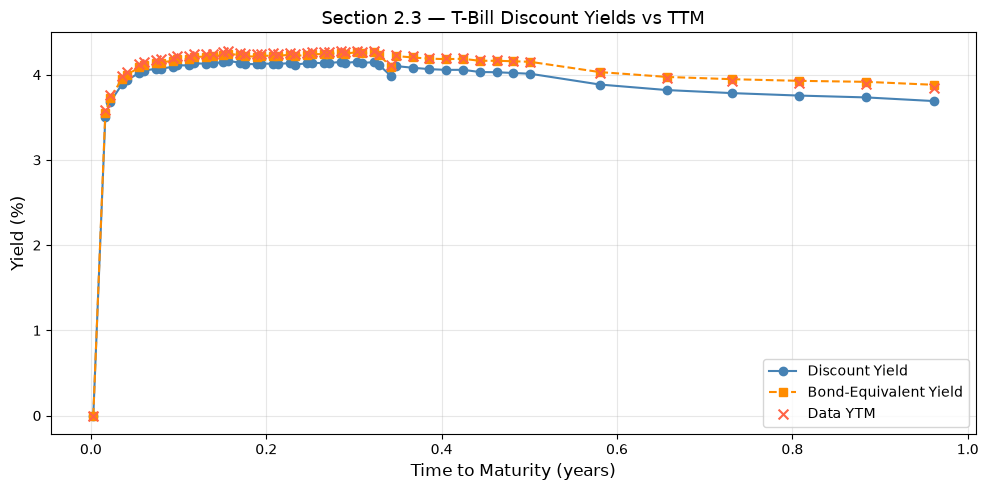

In [17]:
# Plot: Discount yield and BEY for T-bills vs TTM
df_bills_sorted = df_bills.sort_values('TTM')

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_bills_sorted['TTM'], df_bills_sorted['discount_yield'] * 100,
        marker='o', color='steelblue', linewidth=1.5, label='Discount Yield')
ax.plot(df_bills_sorted['TTM'], df_bills_sorted['bey'] * 100,
        marker='s', color='darkorange', linewidth=1.5, linestyle='--', label='Bond-Equivalent Yield')

# Overlay data-provided YTM where available
bills_ytm = df_bills_sorted.dropna(subset=['ytm_data'])
ax.scatter(bills_ytm['TTM'], bills_ytm['ytm_data'] * 100,
           color='tomato', marker='x', s=50, zorder=5, label='Data YTM')

ax.set_xlabel('Time to Maturity (years)', fontsize=12)
ax.set_ylabel('Yield (%)', fontsize=12)
ax.set_title('Section 2.3 — T-Bill Discount Yields vs TTM', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# Summary statistics for discount yields
print("Discount yield summary:")
print(df_bills['discount_yield'].describe().apply(lambda x: f"{x:.6f}"))

Discount yield summary:
count    51.000000
mean      0.039556
std       0.005846
min       0.000000
25%       0.040153
50%       0.041010
75%       0.041338
max       0.041614
Name: discount_yield, dtype: str
